# Wrangling and Summarizing Data

Read this notebook from top to bottom and fill in the code as you go. Work together and discuss with other students in the class. Try to resolve any errors on your own first, but don't get stuck; ask for help!

In addition to writing and running code, be sure to examine any output and interpret the results before moving on.

For many of these questions, there are several ways to do it in Pandas. You only need to choose one that works. But you might want to experiment with multiple ways of doing the same thing to get practice working with Pandas. However, you should generally try to find the simplest solution. In particular, use `groupby` whenever possible to streamline the code.

In [1]:
import pandas as pd

## Titanic data

In [2]:
df_titanic = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/main/data/titanic.csv")
df_titanic

,name,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew
0,"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3.0,NaN
1,"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
2,"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
3,"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3.0,NaN
4,"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2202,"Wynn, Mr. Walter",male,41.0,deck crew,B,England,NaN,NaN,1,NaN,deck crew
2203,"Yearsley, Mr. Harry",male,40.0,victualling crew,S,England,NaN,NaN,1,NaN,victualling crew
2204,"Young, Mr. Francis James",male,32.0,engineering crew,S,England,NaN,NaN,0,NaN,engineering crew
2205,"Zanetti, Sig. Minio",male,20.0,restaurant staff,S,England,NaN,NaN,0,NaN,restaurant staff


1\. Create a new variable "type" that takes values either "passenger" or "crew".

In [3]:
# create function:
def re_class_for_type_var(c):
    if c in ["1st", "2nd", "3rd"]:
        return "passenger"
    else:
        return "crew"

# Make new variable
df_titanic["type"]=df_titanic["class"].map(re_class_for_type_var)


In [4]:
# 2 way table of 2 variables - columns: type, rows: class
pd.crosstab(df_titanic["class"], df_titanic["type"])

type,crew,passenger
class,,
1st,0,324
2nd,0,284
3rd,0,709
deck crew,66,0
engineering crew,324,0
restaurant staff,69,0
victualling crew,431,0


2\. Find the proportion those onboard who were passengers and the proportion who were crew. Do this by creating a Series with these proportions.

In [5]:
# .value_counts() returns frequencies
# normalize=True -> returns proportions
df_titanic["type"].value_counts(normalize=True)

type
passenger    0.596738
crew         0.403262
Name: proportion, dtype: float64

3\. Note that "survived" is a categorical variable that has been one-hot encoded as a dummy (aka Bernoulli aka indicator) numerical variable with 1 = survived and 0 = not survived. (Check its dtype.) Find the proportion of those onboard who survived. You could do this with `value_counts` like for "type", but try a different way that takes advantage of the fact that "survived" is a numerical type. (Hint: what happens if you sum the values of a 1/0 variable? What happens if you take the mean of the values of a 1/0 variable?)

In [6]:
# check survived type
df_titanic["survived"].dtype

# find proportions of those who survived
df_titanic["survived"].value_counts(normalize=True)

survived
0    0.677843
1    0.322157
Name: proportion, dtype: float64

In [7]:
df_titanic["survived"].mean()

np.float64(0.3221567739012234)

4\. Create a crosstab (two-way table) summarizing the joint distribution of "survived" and "type". (Notice that we can treat the dummy variable "survived" as both a categorical variable and a numerical variable, whichever is convenient.)

In [8]:
# YOUR CODE HERE.
pd.crosstab(df_titanic["survived"], df_titanic["type"])

type,crew,passenger
survived,,
0,679,817
1,211,500


5\. Compare the proportion of passengers who survived and the proportion of crew members who survived. Do this by creating a Series that contains these two proportions. Who was more likely to survive: passengers or crew?

Hint: there are a few ways of doing this, several of which avoid explicitly dividing. Can you take advantage of `groupby` and the fact that "survived" is a dummy variable?

In [9]:
# YOUR CODE HERE.
pd.crosstab(df_titanic["type"], df_titanic["survived"], normalize="index")

survived,0,1
type,,
crew,0.762921,0.237079
passenger,0.620349,0.379651


In [10]:
# for those who survived (when = 1)
df_titanic.groupby("type")["survived"].mean()

type
crew         0.237079
passenger    0.379651
Name: survived, dtype: float64

6\. The "gender" variable is coded only as "male" or "female". Among males only, compare the proportion of passengers who survived and the proportion of cew who survived. Among males, who was more likely to survive: passengers or crew? Then do the same thing among females only. Among females, who was more likely to survive: passengers or crew?

Do this by creating a Series that contains the 4 proportions you need. Hint: if you used `groupby` in the previous part you should only need a small change here.

In [11]:
# YOUR CODE HERE.
print(df_titanic.groupby(["gender", "type"])["survived"].mean())

gender  type     
female  crew         0.869565
        passenger    0.727468
male    crew         0.220300
        passenger    0.189189
Name: survived, dtype: float64


7\. Compare your answers to 5 and 6. What do you notice? Can you explain why this happens? Suggest an explanation and then create summaries of the data to support your explanation.

In [12]:
# in 5, we are grouping by only 1 variables
print(df_titanic.groupby(["gender"])["survived"].mean())

gender
female    0.734151
male      0.204889
Name: survived, dtype: float64


In [13]:
#but in 6, we are grouping by 2 variables
print(df_titanic.groupby(["gender"])["type"].value_counts(normalize=True))

gender  type     
female  passenger    0.952965
        crew         0.047035
male    crew         0.504657
        passenger    0.495343
Name: proportion, dtype: float64


## College Scorecard

The [College Scorecard](https://collegescorecard.ed.gov/) was an effort started by the U.S. Department of Education to help students make more informed choices about colleges. Data from 2022 is available at https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/college_scorecard_2022.csv


In [14]:
df_college = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/college_scorecard_2022.csv")

df_college

,Institution,City,State,Undergraduates,Median Earnings
0,Alabama A & M University,Normal,AL,5098.0,39059.0
1,University of Alabama at Birmingham,Birmingham,AL,13284.0,50907.0
2,Amridge University,Montgomery,AL,251.0,37730.0
3,University of Alabama in Huntsville,Huntsville,AL,7358.0,56901.0
4,Alabama State University,Montgomery,AL,3495.0,34018.0
...,...,...,...,...,...
6538,Pennsylvania State University-Penn State York,York,PA,NaN,61185.0
6539,Pennsylvania State University-Penn State Great...,Malvern,PA,NaN,61185.0
6540,Pennsylvania State University-Penn State Harri...,Middletown,PA,NaN,61185.0
6541,Pennsylvania State University-Penn State Brand...,Media,PA,NaN,61185.0


1\. What is the observational unit? Make a guess for how the earnings variable is computed.

The observational unit is the institution. The earnings variables is probably computed by taking the amount of undergraduates and all the earnings then taking the median of the earnings

2\. Write code to find the California Polytechnic row in the data set!

In [15]:
# YOUR CODE HERE
df_college[df_college["Institution"]=="California Polytechnic State University-San Luis Obispo"]
#OR
df_college[df_college["Institution"].str.contains("California Polytechnic")]


,Institution,City,State,Undergraduates,Median Earnings
194,California Polytechnic State University-San Lu...,San Luis Obispo,CA,21090.0,85801.0


3\. The data set contains information about the median earnings of students who attended each college, 10 years after they first enrolled. The earnings are taken directly from the W2 tax forms of all students who received federal financial aid.

Notice the earnings are missing (NaN). Create a subset data frame that only includes colleges with non-missing earnings. Use this subset to answer the remaining questions.

In [16]:
# YOUR CODE HERE.
cleaned_df_college=df_college.dropna(subset=["Median Earnings"])
cleaned_df_college

,Institution,City,State,Undergraduates,Median Earnings
0,Alabama A & M University,Normal,AL,5098.0,39059.0
1,University of Alabama at Birmingham,Birmingham,AL,13284.0,50907.0
2,Amridge University,Montgomery,AL,251.0,37730.0
3,University of Alabama in Huntsville,Huntsville,AL,7358.0,56901.0
4,Alabama State University,Montgomery,AL,3495.0,34018.0
...,...,...,...,...,...
6537,Pennsylvania State University-Penn State Wilke...,Lehman,PA,NaN,61185.0
6538,Pennsylvania State University-Penn State York,York,PA,NaN,61185.0
6539,Pennsylvania State University-Penn State Great...,Malvern,PA,NaN,61185.0
6540,Pennsylvania State University-Penn State Harri...,Middletown,PA,NaN,61185.0


In [17]:
df_college2 = df_college[df_college["Median Earnings"].isna() == False]

4\. Summarize the earnings variable, by finding the sample size, mean, SD, and *five number summary* (minimum, 25th percentile, median, 75th percentile, maximum). Hint: you can do all this with a single command! What is larger: the mean or the median? Why? Then create a histogram of the earnings variable.

In [18]:
# YOUR CODE HERE
cleaned_df_college["Median Earnings"].describe()
#cleaned_df_college["Median Earnings"].mean()
# 41128.80
#cleaned_df_college["Median Earnings"].median()
# 38696

# mean is larger

count      5165.000000
mean      41128.801355
std       16185.531482
min       11085.000000
25%       29448.000000
50%       38696.000000
75%       49077.000000
max      129442.000000
Name: Median Earnings, dtype: float64

<Axes: ylabel='Frequency'>

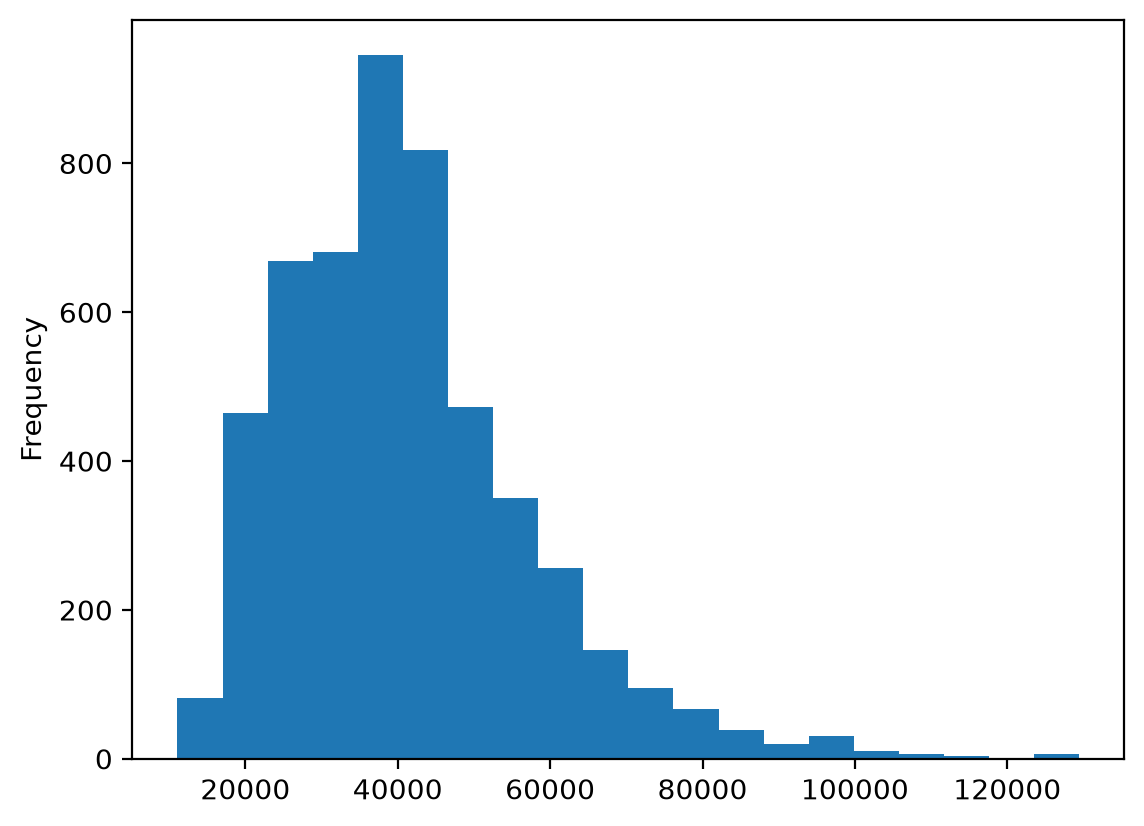

In [19]:
cleaned_df_college["Median Earnings"].plot.hist(bins=20)

5\. Create a new column with the log of earnings, then create a histogram. How does the shape of the histogram of log earnings compare to earnings itself?

In [20]:
# YOUR CODE HERE
import numpy as np
cleaned_df_college["Log of median earnings"] = np.log(cleaned_df_college["Median Earnings"])

#cleaned_df_college["Log of median earnings"].describe()
#cleaned_df_college["Log of median earnings"].mean()
# 10.55
#cleaned_df_college["Log of median earnings"].median()
# 10.56

# median is larger

<Axes: ylabel='Frequency'>

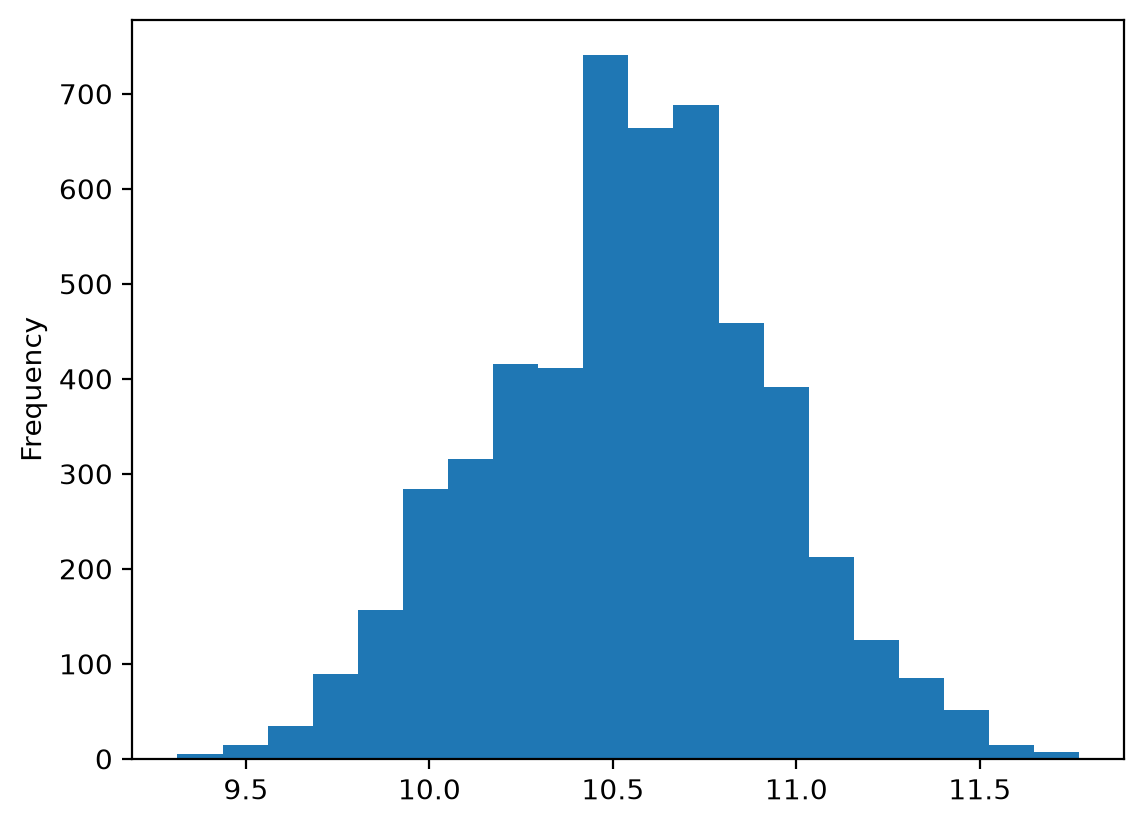

In [21]:
cleaned_df_college["Log of median earnings"].plot.hist(bins=20)

6\. The mean gives every college equal weight. But some colleges are tiny (e.g., San Francisco Conservatory, with 228 undergraduates), while others are large (e.g., Penn State, with 72229 undergraduates!).

If we are interested in what *students* earn, we might want to give more weight to colleges with more students. To do this, we can calculate a **weighted mean**:

$$ \sum_{i=1}^n w_i x_i. $$

In general, the weights $w_1, w_2, ..., w_n$ should all be non-negative and should add up to $1.0$. (For the usual mean, every observation gets equal weight, $1/n$.)

Calculate a weighted mean of earnings, using the undergraduate enrollments as weights. Do this by first adding a "weight" column to the data set (number of undegraduates for the college divided by the total number of undergraduates in the data set).

In [22]:
# YOUR CODE HERE
cleaned_df_college["Weight"] = cleaned_df_college["Undergraduates"] / cleaned_df_college["Undergraduates"].sum()

#cleaned_df_college["Weight"].sum()
(cleaned_df_college["Weight"] * cleaned_df_college["Median Earnings"]).sum()
#50608.338



np.float64(50608.33831282287)

7\. Compute the mean of earnings for each state. Sort the states in descending order of mean earnings. Display the results in a bar chart.

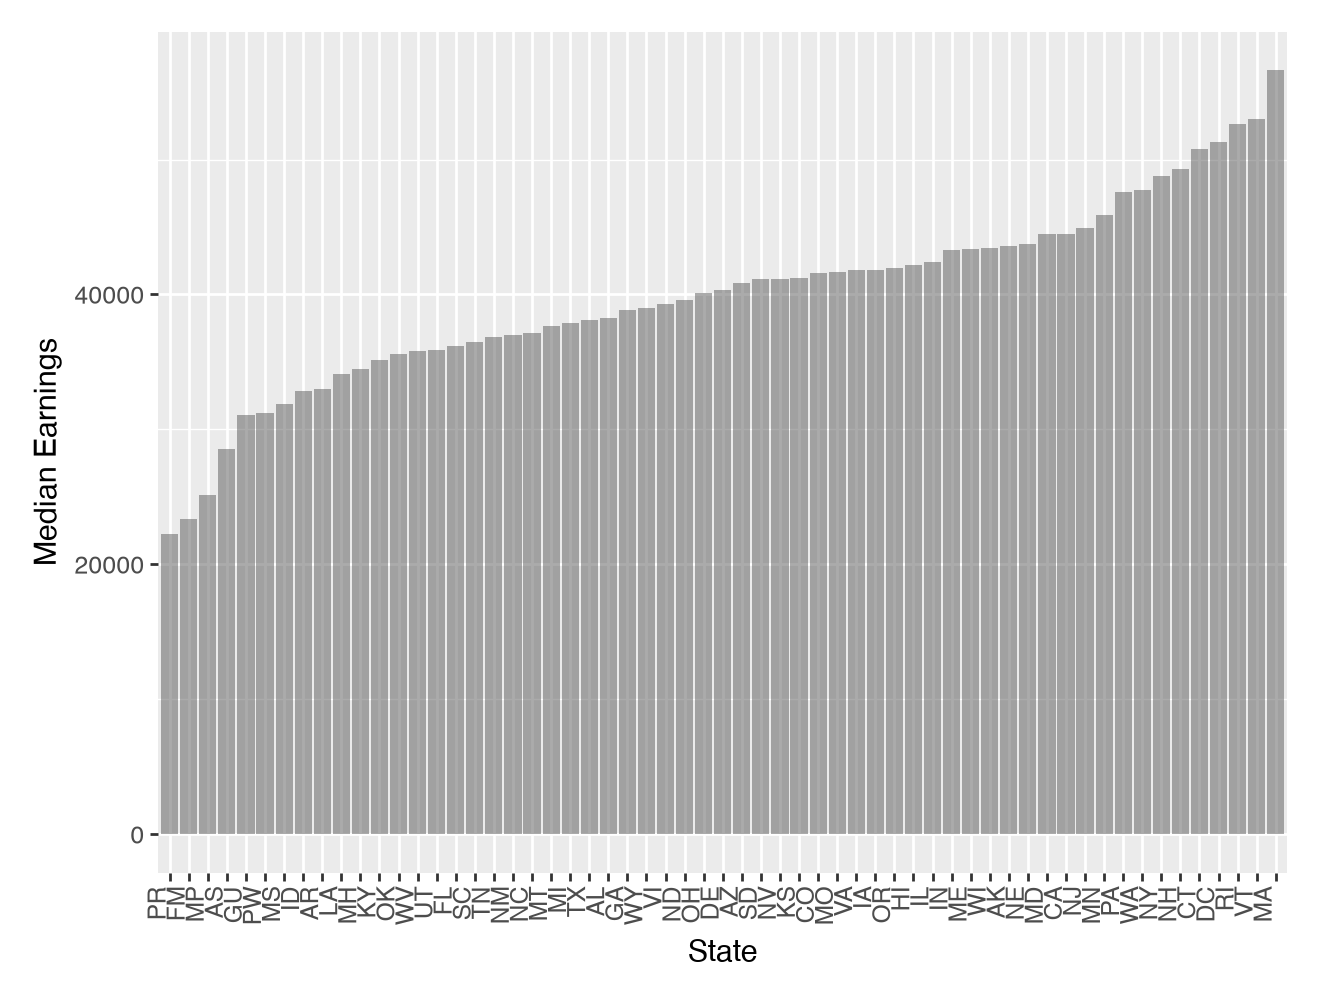

In [23]:
# YOUR CODE HERE.
from plotnine import *
import pandas as pd


mean_earning_state = cleaned_df_college.groupby(["State"])["Median Earnings"].mean().sort_values(ascending=False).reset_index()

# lock in the sort order so plotnine doesn't re-alphabetize the bars
state_order = mean_earning_state["State"].tolist()
mean_earning_state["State"] = mean_earning_state["State"].astype(
    pd.CategoricalDtype(categories=state_order[::-1], ordered=True)
)

(ggplot(mean_earning_state, aes(x = "State", y="Median Earnings"))
 + geom_col(alpha = 0.5)
 + theme(axis_text_x=element_text(rotation=90, hjust=1))

)

8\. Repeat the previous part, but now compute a weighted mean of earnings for each state, using the number of undegraduate enrollments in the state as weights. (Hint: use `groupby` with `transform`.)

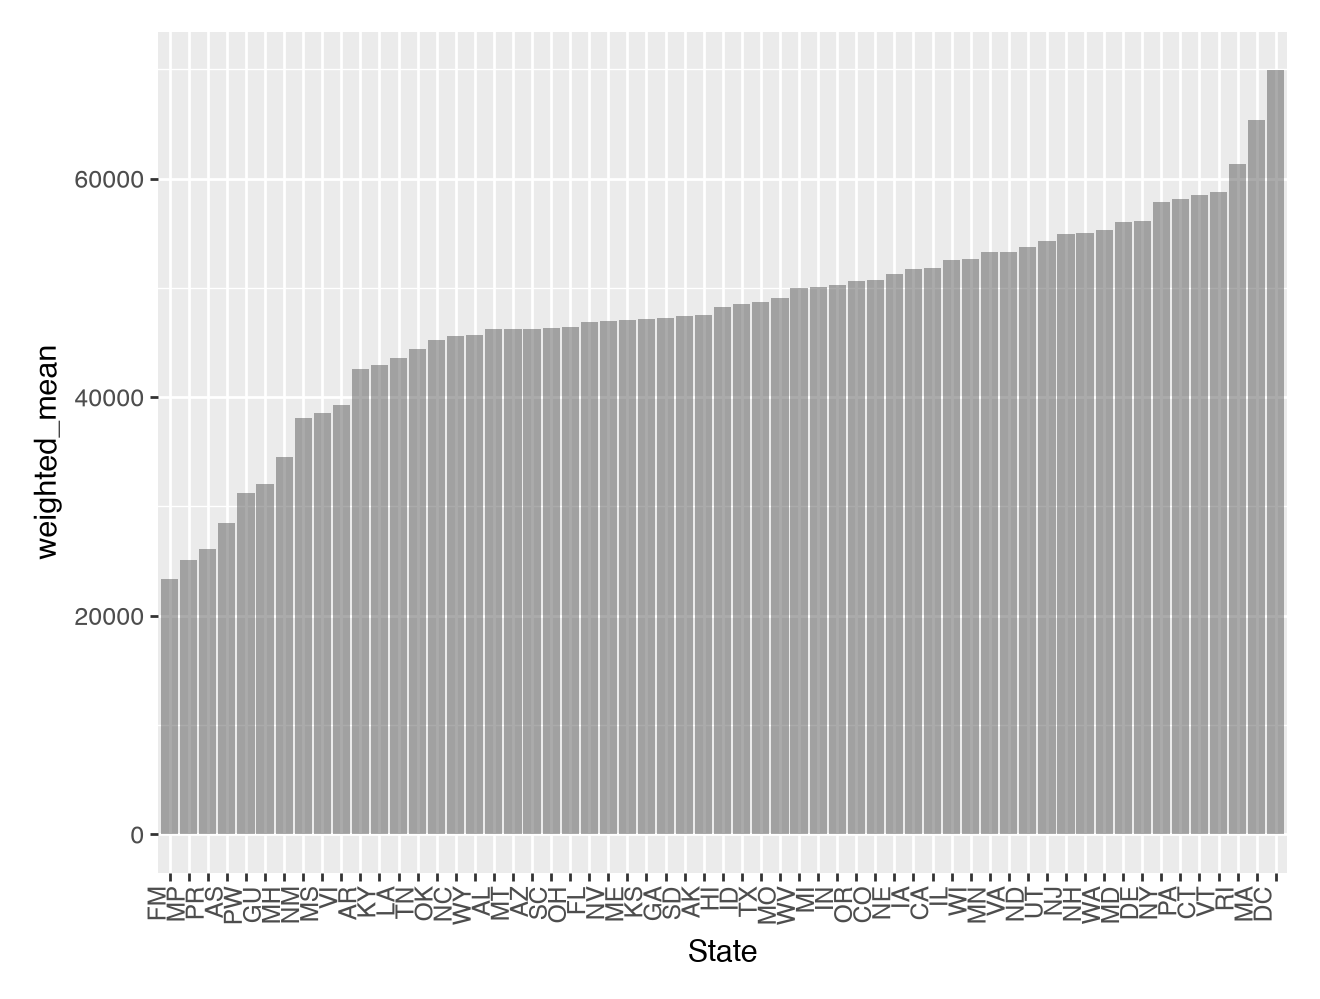

In [24]:
# YOUR CODE HERE.
from plotnine import *
import pandas as pd

# weight of each college in its own state
cleaned_df_college["OwnWeight"] = (cleaned_df_college.groupby("State")["Undergraduates"].transform(lambda x: x / x.sum()))

cleaned_df_college["weighted_mean"] = cleaned_df_college["OwnWeight"] * cleaned_df_college["Median Earnings"]

weighted_mean_by_state = (cleaned_df_college.groupby("State")["weighted_mean"].sum().sort_values(ascending=False).reset_index())

weighted_mean_by_state = weighted_mean_by_state.sort_values("weighted_mean", ascending=False)

# lock in the sort order so plotnine doesn't re-alphabetize the bars
state_order1 = weighted_mean_by_state["State"].tolist()
weighted_mean_by_state["State"] = weighted_mean_by_state["State"].astype(
    pd.CategoricalDtype(categories=state_order1[::-1], ordered=True)
)

(ggplot(weighted_mean_by_state, aes(x = "State", y="weighted_mean"))
 + geom_col(alpha = 0.5)
 + theme(axis_text_x=element_text(rotation=90, hjust=1))

)

## Olympic Men's Gymnastics Data



The file https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv contains scores from the qualification and final rounds of the Olympic men's gymnastics all around competition from 2008 to 2020. (Thanks to Martin Hsu for scraping this data set.)

In [25]:
df_gym = pd.read_csv("https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv")

df_gym

,Pos,Gymnast,NOC,Points,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse,Round,Year
0,1.0,Danell Leyva,USA,91.265,15.100,15.500,15.333,15.866,14.600,14.866,Qualification,2012
1,2.0,David Belyavsky,RUS,90.832,15.100,16.300,15.300,14.866,14.366,14.900,Qualification,2012
2,3.0,Fabian HambÃ¼chen,GER,90.765,15.133,15.833,15.300,15.633,14.766,14.100,Qualification,2012
3,4.0,John Orozco,USA,90.597,15.166,15.800,14.533,15.266,15.066,14.766,Qualification,2012
4,5.0,Kristian Thomas,GBR,90.256,15.366,16.200,14.625,15.366,14.566,14.133,Qualification,2012
...,...,...,...,...,...,...,...,...,...,...,...,...
346,20.0,Daniel Keatings,GBR,89.000,14.850,15.800,14.425,14.225,14.000,15.700,Final,2008
347,21.0,Thomas Bouhail,FRA,87.000,15.200,15.850,14.425,14.475,13.650,13.400,Final,2008
348,22.0,José Luis Fuentes,VEN,86.300,14.175,15.250,15.175,14.150,13.900,13.650,Final,2008
349,23.0,Dzmitry Savitski,BLR,82.175,13.725,15.900,13.400,10.100,15.300,13.750,Final,2008


1\. Create a data frame

- With [Round, Year, Gymnast] as the (multi) index, and
- Containing only the six columns with the event scores, "Floor Exercise" through "Pommelled Horse"

In [26]:
# YOUR CODE HERE.
import pandas as pd
events = ["Floor Exercise", "Horse Vault", "Parallel Bars", "Horizontal Bar", "Rings", "Pommelled Horse"]
# Making new dataframe
scores = df_gym.set_index(["Round", "Year", "Gymnast"])[events]

#printing to see what it looks like
print(scores.head())


                                      Floor Exercise  Horse Vault  \
Round         Year Gymnast                                          
Qualification 2012 Danell Leyva               15.100       15.500   
                   David Belyavsky            15.100       16.300   
                   Fabian HambÃ¼chen          15.133       15.833   
                   John Orozco                15.166       15.800   
                   Kristian Thomas            15.366       16.200   

                                      Parallel Bars  Horizontal Bar   Rings  \
Round         Year Gymnast                                                    
Qualification 2012 Danell Leyva              15.333          15.866  14.600   
                   David Belyavsky           15.300          14.866  14.366   
                   Fabian HambÃ¼chen         15.300          15.633  14.766   
                   John Orozco               14.533          15.266  15.066   
                   Kristian Thomas        

2\. Summarize the scores for each of the six events, by finding the sample size, mean, SD, and *five number summary* (minimum, 25th percentile, median, 75th percentile, maximum). Hint: you can do all this with a single command!

In [27]:
# YOUR CODE HERE
scores.describe()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
count,324.000000,323.000000,323.000000,324.000000,318.000000,325.000000
mean,14.309133,14.976551,14.719288,14.082562,14.237799,13.816723
std,1.254009,0.959876,0.920044,1.299542,0.914523,1.242348
min,1.633000,11.766000,10.200000,0.000000,7.700000,0.000000
25%,13.866000,14.300000,14.233000,13.475000,13.700000,13.266000
50%,14.500000,15.058000,14.900000,14.300000,14.275000,13.925000
75%,15.033000,15.700000,15.350000,14.854000,14.831000,14.566000
max,15.950000,16.775000,16.425000,16.200000,16.650000,16.000000


3\. There are 351 rows in the data frame. Why are the sample sizes different for each event, and not all equal to 351?

**Each gymnast does not compete in all 6 events and they do not all qualify to move onto the next round. This could also be because of injuries that will not allow them to continue competing**

4\. In the all around competition, each gymnast competes all six events, but this doesn't always happen (due to injury, etc). Therefore, there are some missing values in the data. Most of the missing values are coded as `NaN` but some are coded as 0. What would be a more appropriate way to code the missing values in this case: `NaN` or 0? Why?

**NaN is more appropriate to use for those cases because a score of 0 (when they did not even perform) can heavily drag our averages and other stats in our summary down when that is not the case.**

5\. Replace all scores of 0 in the data frame with `NaN`. (Note: It is possible to actually score a 0 on some events, e.g., if you do a vault but don't land feet first. But the few 0s in this data set are for people who didn't compete the event at all.)

In [28]:
# YOUR CODE HERE
scores = scores.replace(0, np.nan)
#checking that there are no more zeros
print((scores == 0).sum()) 

Floor Exercise     0
Horse Vault        0
Parallel Bars      0
Horizontal Bar     0
Rings              0
Pommelled Horse    0
dtype: int64


6\. Summarize the revised data. Which events tend to have the highest scores? The lowest? Which events have the greatest degree of variability in scores? The least?

In [29]:
# YOUR CODE HERE
scores.describe()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
count,324.000000,323.000000,323.000000,323.000000,318.000000,324.000000
mean,14.309133,14.976551,14.719288,14.126161,14.237799,13.859367
std,1.254009,0.959876,0.920044,1.037426,0.914523,0.977423
min,1.633000,11.766000,10.200000,9.433000,7.700000,10.666000
25%,13.866000,14.300000,14.233000,13.475000,13.700000,13.266000
50%,14.500000,15.058000,14.900000,14.300000,14.275000,13.925000
75%,15.033000,15.700000,15.350000,14.858000,14.831000,14.574500
max,15.950000,16.775000,16.425000,16.200000,16.650000,16.000000


**The horse vault tends to have the highest score. On average the rings are lower. Floor Exercise has great variability as the deviation is the greatest. Rings has the least variability.**

7\. Compute the correlation matrix. For which pairs of events is the correlation the highest? The lowest?

In [30]:
# YOUR CODE HERE
scores.corr()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
Floor Exercise,1.000000,0.440092,0.351537,0.378685,0.494417,0.289385
Horse Vault,0.440092,1.000000,0.383301,0.500211,0.595005,0.367616
Parallel Bars,0.351537,0.383301,1.000000,0.557611,0.589963,0.481337
Horizontal Bar,0.378685,0.500211,0.557611,1.000000,0.491114,0.449014
Rings,0.494417,0.595005,0.589963,0.491114,1.000000,0.420985
Pommelled Horse,0.289385,0.367616,0.481337,0.449014,0.420985,1.000000


**The correlation is highest with rings and horse vault. The correlation is lowest with floor exercise and pommelled horse.**

8\. Standardize the scores for each of the six events by subtracting the mean for the event and dividing by its standard deviation. Note: you can do this for all six events at once. You should NOT write a for loop or create a separate line of code for each event.

In [31]:
# YOUR CODE HERE
scores_standardized = (scores-scores.mean())/scores.std()
scores_standardized

Floor Exercise  Horse Vault  \
Round         Year Gymnast                                          
Qualification 2012 Danell Leyva             0.630671     0.545330   
                   David Belyavsky          0.630671     1.378771   
                   Fabian HambÃ¼chen        0.656987     0.892250   
                   John Orozco              0.683303     0.857870   
                   Kristian Thomas          0.842791     1.274591   
...                                              ...          ...   
Final         2008 Daniel Keatings          0.431311     0.857870   
                   Thomas Bouhail           0.710416     0.909960   
                   José Luis Fuentes       -0.106963     0.284879   
                   Dzmitry Savitski        -0.465812     0.962050   
                   Chen Yibing                   NaN     0.962050   

                                      Parallel Bars  Horizontal Bar     Rings  \
Round         Year Gymnast                                                      
Qualification 2012 Danell Leyva            0.667047        1.677073  0.396055   
                   David Belyavsky         0.631179        0.713149  0.140184   
                   Fabian HambÃ¼chen       0.631179        1.452479  0.577570   
                   John Orozco            -0.202477        1.098718  0.905610   
                   Kristian Thomas        -0.102482        1.195111  0.358877   
...                                             ...             ...       ...   
Final         2008 Daniel Keatings        -0.319863        0.095273 -0.260025   
                   Thomas Bouhail         -0.319863        0.336254 -0.642738   
                   José Luis Fuentes       0.495316        0.022979 -0.369372   
                   Dzmitry Savitski       -1.433940       -3.880914  1.161481   
                   Chen Yibing             0.250762       -1.109632  2.637661   

                                      Pommelled Horse  
Round         Year Gymnast                             
Qualification 2012 Danell Leyva              1.029884  
                   David Belyavsky           1.064669  
                   Fabian HambÃ¼chen         0.246191  
                   John Orozco               0.927574  
                   Kristian Thomas           0.279953  
...                                               ...  
Final         2008 Daniel Keatings           1.883148  
                   Thomas Bouhail           -0.469978  
                   José Luis Fuentes        -0.214203  
                   Dzmitry Savitski         -0.111893  
                   Chen Yibing              -0.111893  

[351 rows x 6 columns]

9\. The all around champion is whoever has the highest total score for the six events (in the finals). But who is the "all around standardized value champion"? Create a column that sums the standardized values for each athlete, then sort the data frame in descending order by that column. Note: you should NOT have to manually add six columns.

In [32]:
# YOUR CODE HERE
#Total each person's event score
scores_standardized["Total"] = scores_standardized.sum(axis=1)
scores_standardized.sort_values("Total", ascending=False)

#Only look at the finals scores
finals_standardized = scores_standardized.loc["Final"] 
finals_standardized.sort_values("Total", ascending=False)

print(finals_standardized.head())

                       Floor Exercise  Horse Vault  Parallel Bars  \
Year Gymnast                                                        
2012 Kohei Uchimura          0.630671     1.343350       0.658351   
     Marcel Nguyen           0.790160     0.718269       1.210499   
     Danell Leyva            0.842791     0.614089       1.210499   
     Mykola Kuksenkov        0.258266     0.579709       0.739869   
     David Belyavsky         0.125093     1.274591       0.485534   

                       Horizontal Bar     Rings  Pommelled Horse     Total  
Year Gymnast                                                                
2012 Kohei Uchimura          1.420669  1.197566         1.234504  6.485111  
     Marcel Nguyen           1.035099  1.233650        -0.197834  4.789843  
     Danell Leyva            1.517062  0.541486        -0.367668  4.358258  
     Mykola Kuksenkov        0.905934  1.052135         0.757740  4.293652  
     David Belyavsky         0.616756  0.650832       

**Kohei Uchimura is the all around champion.**

10\. Compute the mean score for each event in each year. How do the means change over time? Why do you think this happened?

In [33]:
# YOUR CODE HERE.
scores.groupby("Year").mean()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
Year,,,,,,
2008,14.720250,15.841753,15.125758,14.563750,14.850532,14.248750
2012,14.495154,15.484308,14.663231,14.365922,14.441462,13.787172
2016,14.134667,14.496068,14.787083,14.246315,14.201514,14.051319
2020,13.841989,14.046398,14.242529,13.336919,13.453632,13.312341


**The scores have been decreasing over time. Maybe an athlete that really excelled retired which would bring the mean scores down.**

11\. Choose one event and for that event create a plot with a single panel that summarizes the distribution of scores for each of the four years. Describe what you see.

/opt/anaconda3/lib/python3.14/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 33 rows containing non-finite values.


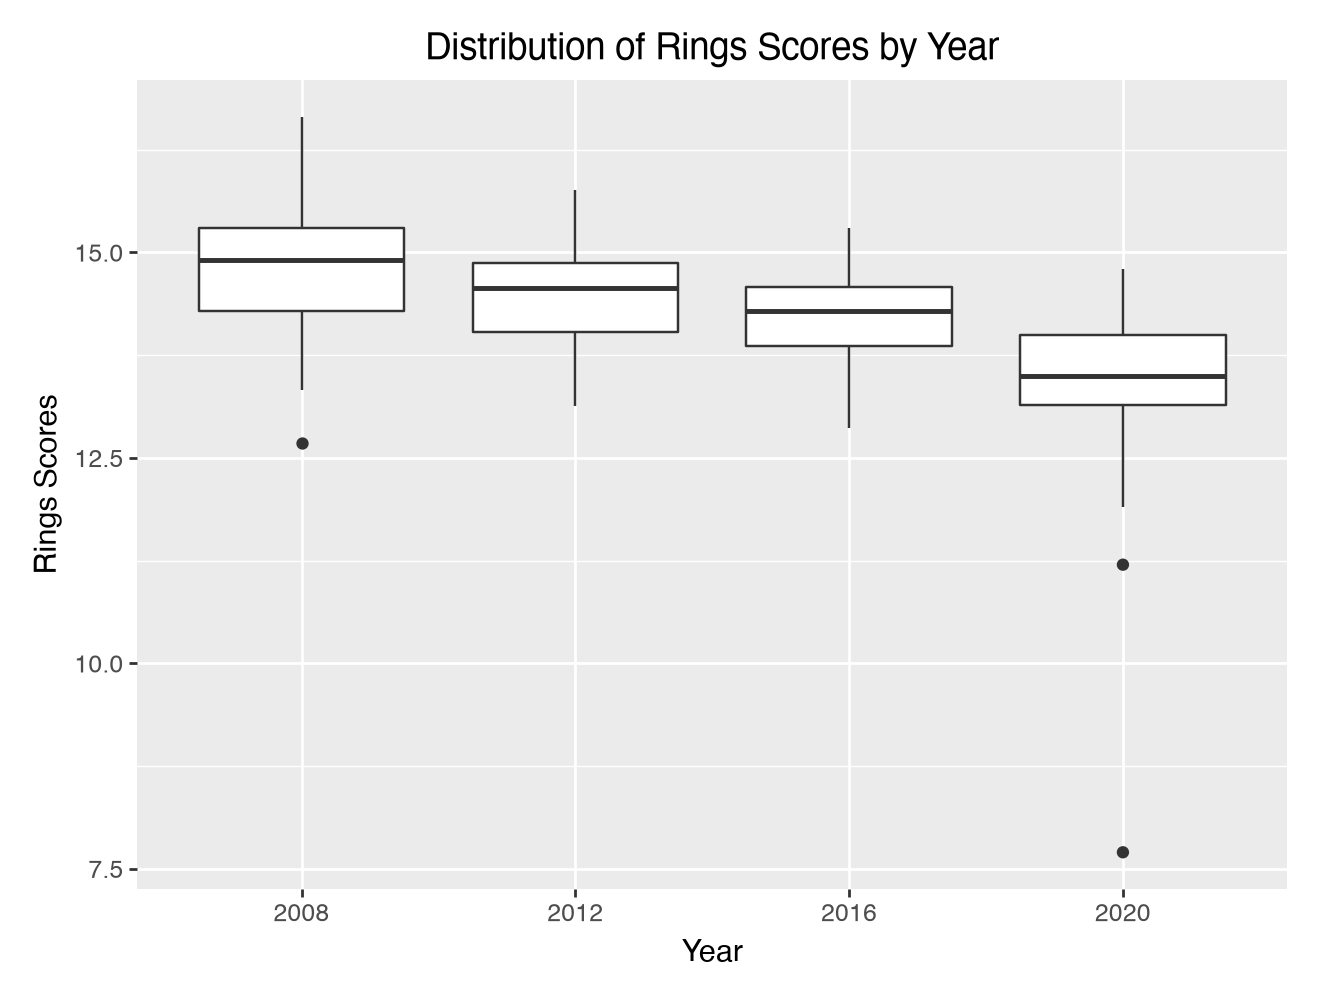

In [34]:
# YOUR CODE HERE.
#scores.groupby("Year")["Rings"].describe()
rings = scores[["Rings"]].reset_index()
(
    ggplot(rings, aes(x="factor(Year)", y="Rings"))
    + geom_boxplot()
    + labs(x="Year", y="Rings Scores", title="Distribution of Rings Scores by Year")
)

12\. Standardize the scores for each of the six events by subtracting the mean for the event and dividing by its standard deviation *within each year*. Note: you can do this for all six events at once. You should NOT write a for loop or create a separate line of code for each event.


In [35]:
# YOUR CODE HERE.
scores_standardized_within_year = (scores - scores.groupby("Year").mean()) / scores.groupby("Year").std()

scores_standardized_within_year

Floor Exercise  Horse Vault  \
Round         Year Gymnast                                          
Qualification 2012 Danell Leyva             0.753096     0.027915   
                   David Belyavsky          0.753096     1.451057   
                   Fabian HambÃ¼chen        0.794185     0.620298   
                   John Orozco              0.835273     0.561594   
                   Kristian Thomas          1.084294     1.273164   
...                                              ...          ...   
Final         2008 Daniel Keatings          0.098864    -0.076907   
                   Thomas Bouhail           0.365547     0.015192   
                   José Luis Fuentes       -0.415455    -1.089993   
                   Dzmitry Savitski        -0.758335     0.107290   
                   Chen Yibing                   NaN     0.107290   

                                      Parallel Bars  Horizontal Bar     Rings  \
Round         Year Gymnast                                                      
Qualification 2012 Danell Leyva            1.002995        1.708332  0.269011   
                   David Belyavsky         0.953577        0.569503 -0.128045   
                   Fabian HambÃ¼chen       0.953577        1.442985  0.550683   
                   John Orozco            -0.195024        1.025035  1.059729   
                   Kristian Thomas        -0.057251        1.138917  0.211319   
...                                             ...             ...       ...   
Final         2008 Daniel Keatings        -0.896615       -0.385333 -1.098537   
                   Thomas Bouhail         -0.896615       -0.100954 -1.550593   
                   José Luis Fuentes       0.063005       -0.470647 -1.227696   
                   Dzmitry Savitski       -2.208096       -5.077583  0.580528   
                   Chen Yibing            -0.224881       -1.807227  2.324171   

                                      Pommelled Horse  
Round         Year Gymnast                             
Qualification 2012 Danell Leyva              1.232874  
                   David Belyavsky           1.271729  
                   Fabian HambÃ¼chen         0.357497  
                   John Orozco               1.118595  
                   Kristian Thomas           0.395209  
...                                               ...  
Final         2008 Daniel Keatings           1.745577  
                   Thomas Bouhail           -1.020884  
                   José Luis Fuentes        -0.720182  
                   Dzmitry Savitski         -0.599901  
                   Chen Yibing              -0.599901  

[351 rows x 6 columns]

13\. If we standardize within each year, which athletes (and rounds and year) had the highest total standardized values? Basically repeat part 9 but with standardization within each year.

In [ ]:
# YOUR CODE HERE.
#Total each person's standardized event score
scores_standardized_within_year["Total"] = scores_standardized_within_year.sum(axis=1)
scores_standardized_within_year.sort_values("Total", ascending=False)

#Only look at the standardized finals scores
finals_standardized_within_year = scores_standardized_within_year.loc["Final"] 
finals_standardized_within_year.sort_values("Total", ascending=False)

#print(finals_standardized_within_year.head())

highest_per_year = finals_standardized_within_year.loc[finals_standardized_within_year.groupby("Year")["Total"].idxmax()]

print(highest_per_year)

                      Floor Exercise  Horse Vault  Parallel Bars  \
Year Gymnast                                                       
2008 Yang Wei               0.403645     1.304573       1.246537   
2012 Kohei Uchimura         0.753096     1.390574       0.991015   
2016 Oleh Verniaiev         0.520383     1.475149       1.524323   
2020 Daiki Hashimoto        1.382156     1.070152       1.007048   

                      Horizontal Bar     Rings  Pommelled Horse     Total  
Year Gymnast                                                               
2008 Yang Wei               0.240300  2.291882         1.234383  6.721320  
2012 Kohei Uchimura         1.405403  1.512779         1.461432  7.514300  
2016 Oleh Verniaiev         0.534169  2.005141         1.554973  7.614139  
2020 Daiki Hashimoto        1.802342  0.085413         1.898201  7.245313  


**Yang Wei, Kohei Uchimura, Oleh Verniaiev, and Daiki Hashimoto had the highest standardized final scores for each year (2008, 2012, 2016, 2020).**